In [2]:
import sys
from pathlib import Path

file_path    = str(Path.cwd())
project_path = str(Path.cwd().parent)

sys.path.append(project_path)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from dpd.optuna_tasks import get_pareto

In [4]:
font = {'size':14}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

In [5]:
EVM_ARVTDNN = np.array([ np.loadtxt(file_path + f"\\ARVTDNN\\study{1}\\models\\metrics_{j}.txt")[0] for j in range(500) ])
EVM_ETDNN   = np.array([ np.loadtxt(file_path + f"\\ETDNN\\study{1}\\models\\metrics_{j}.txt")[0] for j in range(460) ])
EVM_MP      = np.array([ np.loadtxt(file_path + f"\\MP\\study{1}\\models\\metrics_{j}.txt")[0] for j in range(120) ])
EVM_ETDKAN  = np.array([ np.loadtxt(file_path + f"\\ETDKAN\\study{1}\\models\\metrics_{j}.txt")[0] for j in range(435) ])
EVM_symbETDKAN = np.array([ np.loadtxt(file_path + f"\\Symb_ETDKAN\\study{1}\\models\\metrics_{j}.txt")[0] for j in range(150) ])

ACLR_ARVTDNN = np.array([ np.loadtxt(file_path + f"\\ARVTDNN\\study{2}\\models\\metrics_{j}.txt")[1] for j in range(500) ])
ACLR_ETDNN   = np.array([ np.loadtxt(file_path + f"\\ETDNN\\study{1}\\models\\metrics_{j}.txt")[1] for j in range(460) ])
ACLR_MP      = np.array([ np.loadtxt(file_path + f"\\MP\\study{1}\\models\\metrics_{j}.txt")[1] for j in range(120) ])
ACLR_ETDKAN  = np.array([ np.loadtxt(file_path + f"\\ETDKAN\\study{1}\\models\\metrics_{j}.txt")[1] for j in range(435) ])
ACLR_symbETDKAN = np.array([ np.loadtxt(file_path + f"\\Symb_ETDKAN\\study{1}\\models\\metrics_{j}.txt")[1] for j in range(150) ])

NFLOPs_EVM_ARVTDNN  = np.array([ np.loadtxt(file_path + f"\\ARVTDNN\\study{1}\\models\\metrics_{j}.txt")[2] for j in range(500) ])
NFLOPs_ACLR_ARVTDNN = np.array([ np.loadtxt(file_path + f"\\ARVTDNN\\study{2}\\models\\metrics_{j}.txt")[2] for j in range(500) ])

NFLOPs_EVM_ETDNN  = np.array([ np.loadtxt(file_path + f"\\ETDNN\\study{1}\\models\\metrics_{j}.txt")[2] for j in range(460) ])
NFLOPs_ACLR_ETDNN = np.array([ np.loadtxt(file_path + f"\\ETDNN\\study{1}\\models\\metrics_{j}.txt")[2] for j in range(460) ])

NFLOPs_EVM_MP  = np.array([ np.loadtxt(file_path + f"\\MP\\study{1}\\models\\metrics_{j}.txt")[2] for j in range(120) ])
NFLOPs_ACLR_MP = np.array([ np.loadtxt(file_path + f"\\MP\\study{1}\\models\\metrics_{j}.txt")[2] for j in range(120) ])

NFLOPs_EVM_ETDKAN  = np.array([ np.loadtxt(file_path + f"\\ETDKAN\\study{1}\\models\\metrics_{j}.txt")[2] for j in range(435) ])
NFLOPs_ACLR_ETDKAN = np.array([ np.loadtxt(file_path + f"\\ETDKAN\\study{1}\\models\\metrics_{j}.txt")[2] for j in range(435) ])

NFLOPs_min_EVM_symbETDKAN  = np.array([ np.loadtxt(file_path + f"\\Symb_ETDKAN\\study{1}\\models\\metrics_{j}.txt")[2] for j in range(150) ])
NFLOPs_min_ACLR_symbETDKAN = np.array([ np.loadtxt(file_path + f"\\Symb_ETDKAN\\study{1}\\models\\metrics_{j}.txt")[2] for j in range(150) ])
NFLOPs_max_EVM_symbETDKAN  = np.array([ np.loadtxt(file_path + f"\\Symb_ETDKAN\\study{1}\\models\\metrics_{j}.txt")[3] for j in range(150) ])
NFLOPs_max_ACLR_symbETDKAN = np.array([ np.loadtxt(file_path + f"\\Symb_ETDKAN\\study{1}\\models\\metrics_{j}.txt")[3] for j in range(150) ])

In [117]:
mask_nan = ~np.isnan(ACLR_symbETDKAN)

C:\Users\PC\AppData\Local\Temp\ipykernel_11864\2066435542.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


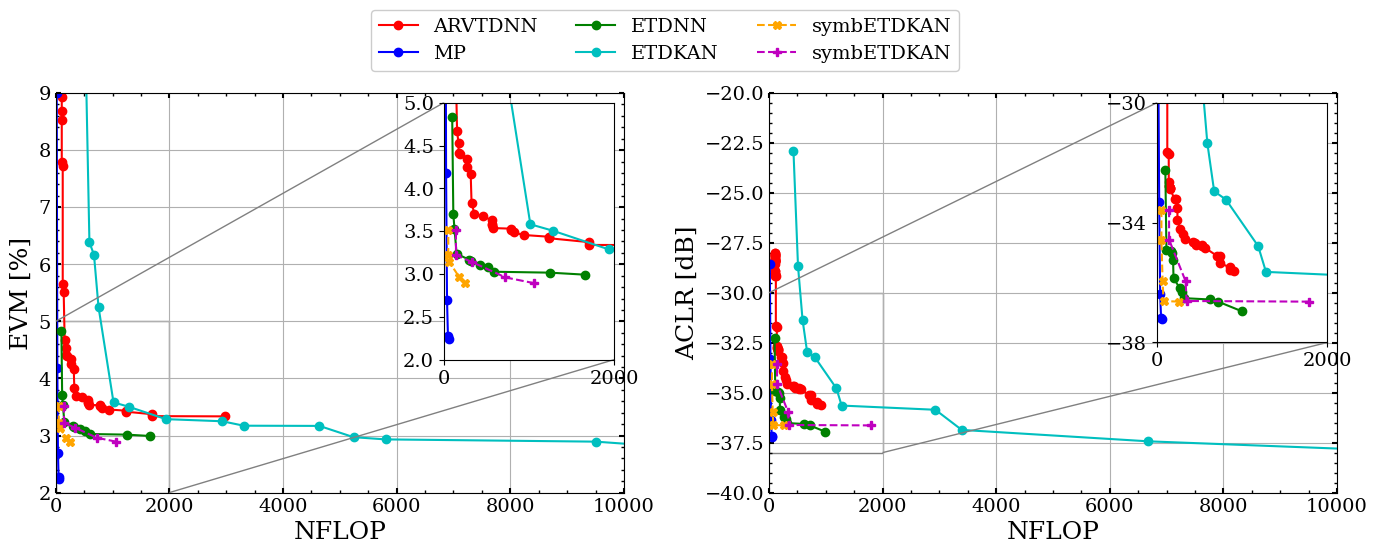

In [143]:
fig, axs = plt.subplots(1, 2, figsize = (14, 5))

dpd_type    = ["ARVTDNN", "MP", "ETDNN", "ETDKAN", "symbETDKAN"]
evm_list    = [EVM_ARVTDNN, EVM_MP, EVM_ETDNN, EVM_ETDKAN, EVM_symbETDKAN]
aclr_list   = [ACLR_ARVTDNN, ACLR_MP, ACLR_ETDNN, ACLR_ETDKAN, ACLR_symbETDKAN]
nflops_evm_list = [NFLOPs_EVM_ARVTDNN, NFLOPs_EVM_MP, NFLOPs_EVM_ETDNN, NFLOPs_EVM_ETDKAN, (NFLOPs_min_EVM_symbETDKAN, NFLOPs_max_EVM_symbETDKAN)]
nflops_aclr_list = [NFLOPs_ACLR_ARVTDNN, NFLOPs_ACLR_MP, NFLOPs_ACLR_ETDNN, NFLOPs_ACLR_ETDKAN, (NFLOPs_min_ACLR_symbETDKAN, NFLOPs_max_ACLR_symbETDKAN)]
color_list  = ["r", "b", "g", "c", "k"]

axins_evm  = zoomed_inset_axes(axs[0], 1.5, loc = "upper right")
axins_aclr = zoomed_inset_axes(axs[1], 1.5, loc = "upper right")

for i in range(4):
    # EVM vs NFLOPs
    pareto_solutions_evm, pareto_trials_evm   = get_pareto(evm_list[i], nflops_evm_list[i], evm_list[i].size)
    pareto_solutions_aclr, pareto_trials_aclr = get_pareto(aclr_list[i], nflops_aclr_list[i], aclr_list[i].size)
    
    axs[0].plot(pareto_solutions_evm[:,1], pareto_solutions_evm[:,0], "-o", color = color_list[i], label = f"{dpd_type[i]}")
    axins_evm.plot(pareto_solutions_evm[:,1], pareto_solutions_evm[:,0], "-o", color = color_list[i], label = f"{dpd_type[i]}")
    axs[1].plot(pareto_solutions_aclr[:,1], pareto_solutions_aclr[:,0], "-o", color = color_list[i], label = f"{dpd_type[i]}")
    axins_aclr.plot(pareto_solutions_aclr[:,1], pareto_solutions_aclr[:,0], "-o", color = color_list[i], label = f"{dpd_type[i]}")
    
# Symb ETDKAN
pareto_solutions_evm_min, pareto_trials_evm_min   = get_pareto(evm_list[-1][mask_nan], nflops_evm_list[-1][0][mask_nan], np.sum(mask_nan))
pareto_solutions_aclr_min, pareto_trials_aclr_min = get_pareto(aclr_list[-1][mask_nan], nflops_aclr_list[-1][0][mask_nan], np.sum(mask_nan))

pareto_solutions_evm_max, pareto_trials_evm_max   = get_pareto(evm_list[-1][mask_nan], nflops_evm_list[-1][1][mask_nan], np.sum(mask_nan))
pareto_solutions_aclr_max, pareto_trials_aclr_max = get_pareto(aclr_list[-1][mask_nan], nflops_aclr_list[-1][1][mask_nan], np.sum(mask_nan))

axs[0].plot(pareto_solutions_evm_min[:,1], pareto_solutions_evm_max[:,0], "--X", color = "orange", label = f"{dpd_type[-1]}")
axs[0].plot(pareto_solutions_evm_max[:,1], pareto_solutions_evm_max[:,0], "--P", color = "m", label = f"{dpd_type[-1]}")
axins_evm.plot(pareto_solutions_evm_min[:,1], pareto_solutions_evm_max[:,0], "--X", color = "orange", label = f"{dpd_type[-1]}")
axins_evm.plot(pareto_solutions_evm_max[:,1], pareto_solutions_evm_max[:,0], "--P", color = "m", label = f"{dpd_type[-1]}")

axs[1].plot(pareto_solutions_aclr_min[:,1], pareto_solutions_aclr_max[:,0], "--X", color = "orange")
axs[1].plot(pareto_solutions_aclr_max[:,1], pareto_solutions_aclr_max[:,0], "--P", color = "m")
axins_aclr.plot(pareto_solutions_aclr_min[:,1], pareto_solutions_aclr_max[:,0], "--X", color = "orange")
axins_aclr.plot(pareto_solutions_aclr_max[:,1], pareto_solutions_aclr_max[:,0], "--P", color = "m")

axs[0].set_xlim(0, 10e3)
axs[0].set_ylim(2., 9)
axs[0].set_xlabel("NFLOP", fontsize = 18)
axs[0].set_ylabel("EVM [%]", fontsize = 18)

axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[0].grid()
#axs[0].legend(framealpha = 1, fontsize = 14, bbox_to_anchor = (1, 1.2), ncols = 3)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, ncols = 3, framealpha = 1, bbox_to_anchor = (0.7, 1.13))

axs[1].set_xlim(0, 10e3)
axs[1].set_ylim(-40, -20)
axs[1].set_xlabel("NFLOP", fontsize = 18)
axs[1].set_ylabel("ACLR [dB]", fontsize = 18)

axins_evm.set_xlim(0, 2e3)
axins_evm.set_ylim(2, 5)
axins_evm.set_xticks(np.arange(0, 2001, 2000))
#axins_evm.set_yticks(np.arange()

axins_aclr.set_xlim(0, 2e3)
axins_aclr.set_ylim(-38, -30)
axins_aclr.set_xticks(np.arange(0, 2001, 2000))
axins_aclr.set_yticks(np.arange(-38, -29, 4))

mark_inset(axs[0], axins_evm, loc1 = 2, loc2 = 4, fc = "none", ec = "0.5")
mark_inset(axs[1], axins_aclr, loc1 = 2, loc2 = 4, fc = "none", ec = "0.5")

axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].grid()
#axs[1].legend(framealpha = 1, loc = "upper right", fontsize = 14)

fig.tight_layout()
#axs[0].axhline(2.25)
fig.savefig("plot_pareto_EVM_ACLR.png", dpi = 300, bbox_inches='tight')

In [50]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset


In [ ]:

fig, ax = plt.subplots(figsize=(5,4))

extent = (0, 100, 0, 50)

x, y = np.mgrid[-5:5:100j, -5:5:100j]
z = np.sin(2*x)*np.sin(y**2)

ax.contourf(x, y, z, cmap="YlGnBu_r")

axins = zoomed_inset_axes(ax, 2, loc=1)
axins.contourf(x, y, z, cmap="YlGnBu_r")
axins.set_xlim(1, 2)
axins.set_ylim(1, 2)
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.xticks(visible=False)
plt.yticks(visible=False)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")
plt.draw()
plt.show()